# Calculate Probabilistic Forecast Data (Cleaned)

**Date created:** September 3rd, 2025 

**Date edited:** October 21st, 2025

**Author:** Prakrut Kansara, edited by Kris Su

**Description:** This notebook calculates the `TERCILE CATEGORY PROBABILITY EXCEEDANCE` used for the heatmap figure in the AmazonHydroViewer webapp.

**Improvements in this version:**
- Proper soil profile level handling and saving
- Memory management with garbage collection
- Better path handling with pathlib
- Improved error handling and logging
- Removed duplicate function definitions
- Enhanced documentation
- Fixed `.items()` bug
- Proper soil profile level handling
- Memory management with garbage collection
- **NEW:** Extract river networks for each tercile category separately
- **NEW:** Save separate GeoJSON files for below-normal, normal, and above-normal categories
- Enhanced error handling and documentation

**Tercile Categories:**
- Category 0: Below normal (< 33rd percentile) - typically dry conditions
- Category 1: Normal (33rd-67th percentile) - typical conditions  
- Category 2: Above normal (> 67th percentile) - typically wet conditions

**Surface variable units:**
- `Rainf_tavg`: mm/day
- `Qair_f_tavg`: g/kg
- `Qs_tavg`: mm/day
- `Evap_tavg`: mm/day
- `Tair_f_tavg`: degree Celsius
- `SoilMoist_inst`: m³/m³ (by profile level)
- `SoilTemp_inst`: degree Celsius (by profile level)
- `Streamflow_tavg`: m³/s

In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import re
import gc
from tqdm import tqdm
from datetime import datetime
from pathlib import Path
from shapely.geometry import box

## Functions

In [10]:
def read_trim_forecast(file_path, va):
    """
    Read forecast data for a specific variable.
    
    Args:
        file_path (str): Path to forecast NetCDF file
        va (str): Variable name to extract

    Returns:
        xarray.DataArray: Forecast data for the variable
    """
    try:
        forecast_data = xr.open_dataset(file_path)[va]
        return forecast_data
    except KeyError:
        print(f'ERROR: Variable {va} not found in dataset {file_path}')
        raise

In [11]:
def read_trim_hindcast(file_path, va):
    """
    Read hindcast data for a specific variable from multiple files.
    
    Args:
        file_path (str or list): Path(s) to hindcast NetCDF file(s)
        va (str): Variable name to extract
        
    Returns:
        xarray.DataArray: Hindcast data for the variable, chunked by time
    """
    try:
        hindcast_data = xr.open_mfdataset(file_path, join='outer')[va]
        return hindcast_data
    except KeyError:
        print(f'ERROR: Variable {va} not found in hindcast dataset')
        raise

In [12]:
def get_thresh(icat, quantiles, xrds, dims=['ensemble', 'time']):
    """
    Calculate threshold boundaries for a category based on quantiles.
    
    Args:
        icat (int): Category index (0, 1, 2 for terciles)
        quantiles (list): Quantile boundaries (e.g., [1/3, 2/3] for terciles)
        xrds (xarray.DataArray): Data array to calculate quantiles from
        dims (list): Dimensions to calculate quantiles over
    
    Returns:
        tuple: (lower_threshold, upper_threshold) for the category
    """
    if not all(elem in xrds.dims for elem in dims): 
        raise Exception(f'Some dimensions in {dims} not present in xr.DataArray {xrds.dims}')

    if icat == 0:  # Below normal category
        xrds_lo = -np.inf
        xrds_hi = xrds.quantile(quantiles[icat], dim=dims)
    elif icat == len(quantiles):  # Above normal category
        xrds_lo = xrds.quantile(quantiles[icat-1], dim=dims) 
        xrds_hi = np.inf
    else:  # Normal category
        xrds_lo = xrds.quantile(quantiles[icat-1], dim=dims)
        xrds_hi = xrds.quantile(quantiles[icat], dim=dims)
    
    return xrds_lo, xrds_hi

In [13]:
def calculate_probabilities(hcst, fcst, quantiles=[1/3., 2/3.]):
    """
    Calculate tercile category probability exceedance for ensemble forecast.
    
    Uses hindcast to define climatological tercile boundaries (below-normal, 
    normal, above-normal), then calculates probability that forecast ensemble
    members fall into each category.
    
    Args:
        hcst (xarray.DataArray): Hindcast data with dims [time, ensemble, lat, lon]
        fcst (xarray.DataArray): Forecast data with dims [time, ensemble, lat, lon]
        quantiles (list): Category boundaries (default: terciles at [1/3, 2/3])
    
    Returns:
        xarray.DataArray: Probability (0-1) that forecast falls in each category
                         Dims: [category, time, lat, lon]
                         - Category 0 = below normal (< 33rd percentile)
                         - Category 1 = normal (33rd-67th percentile)
                         - Category 2 = above normal (> 67th percentile)
    """
    print('Computing probabilities...')
    numcategories = len(quantiles) + 1  # 3 categories for terciles

    # Mask out 0 values in forecast (assumes 0 = missing/invalid)
    # NOTE: Verify this is appropriate for your data
    fcst_masked = fcst.where(fcst != 0)

    l_probs = []
    for icat in range(numcategories):
        print(f'  category={icat}')
        h_lo, h_hi = get_thresh(icat, quantiles, hcst)
        
        # Count fraction of ensemble members in this category
        prob = np.logical_and(fcst_masked > h_lo, fcst_masked <= h_hi).sum('ensemble') / float(fcst_masked.sizes['ensemble'])
        
        # Remove quantile coordinate if present (artifact from threshold calculation)
        if 'quantile' in prob.coords:
            prob = prob.drop_vars('quantile')
        
        l_probs.append(prob.assign_coords({'category': icat}))
    
    probs = xr.concat(l_probs, dim='category')
    return probs

## River Network Extraction

In [14]:
def as_2d(da, xdim="lon", ydim="lat"): 
    """
    Convert multi-dimensional data array to 2D spatial grid.
    
    Drops size-1 dimensions and averages over non-spatial dimensions.
    
    Args:
        da (xarray.DataArray): Input data array
        xdim (str): Longitude dimension name
        ydim (str): Latitude dimension name
        
    Returns:
        xarray.DataArray: 2D array with dims (lat, lon)
    """
    # Drop size-1 dims
    da = da.squeeze(drop=True)
    # Reduce any leftover non-spatial dims (e.g., ensemble/step/time) to mean
    reduce_dims = [d for d in da.dims if d not in (ydim, xdim)]
    if reduce_dims:
        da = da.mean(dim=reduce_dims, skipna=True)
    # Ensure order is (lat, lon)
    return da.transpose(ydim, xdim)

In [48]:
def extract_river_network_by_category(
    streamflow_data, 
    probability_data, 
    flow_threshold=50.0,
    time_index=0
):
    """
    Extract river network polygons for each tercile category separately.
    
    Args:
        streamflow_data (xr.DataArray): Hindcast streamflow data for threshold filtering
        probability_data (xr.DataArray): Probability data with 'category' dimension
        flow_threshold (float): Minimum probability to include cell in river network
        time_index (int): Time index to select (default: 0 for first forecast month)
        
    Returns:
        dict: Dictionary with keys 'cat_0', 'cat_1', 'cat_2' containing GeoDataFrames
    """
    # Select time step for streamflow (for spatial structure)
    #streamflow_2d = as_2d(streamflow_data.isel(time=-1))
    
    # Get spatial coordinates
    lon = streamflow_data["lon"].values
    lat = streamflow_data["lat"].values
    river_mask = streamflow_data.values
    
    # Create mask for river cells (where streamflow >= threshold)
    #river_mask = np.isfinite(flow_values) & (flow_values >= flow_threshold)
    ii, jj = np.where(river_mask)
    
    print(f"Found {len(ii)} river cells above threshold {flow_threshold} %")
    
    # Extract each category
    category_gdfs = {}
    category_names = {
        0: 'below_normal',
        1: 'near_normal', 
        2: 'above_normal'
    }
    
    for cat_idx in range(3):  # Three tercile categories
        print(f"\nProcessing Category {cat_idx}: {category_names[cat_idx]}")
        
        # Select this category's probability data
        cat_probs = probability_data.sel(category=cat_idx).isel(time=time_index)
        prob_2d = as_2d(cat_probs)
        prob_values = prob_2d.values
        
        # Build polygons only for river cells
        geoms = []
        attrs = []
        
        for i, j in zip(ii, jj):
            if i+1 < len(lat) and j+1 < len(lon):
                prob_val = prob_values[i, j]
                
                # Only include if probability is not NaN
                if np.isfinite(prob_val):
                    # Create polygon for this grid cell
                    geom = box(lon[j], lat[i+1], lon[j+1], lat[i])
                    geoms.append(geom)
                    
                    # Store attributes
                    attrs.append({
                        "streamflow": float(river_mask[i, j]),
                        "probability": float(prob_val),
                        "category": cat_idx,
                        "category_name": category_names[cat_idx],
                        "lat": float(lat[i]),
                        "lon": float(lon[j])
                    })
        
        # Create GeoDataFrame
        if geoms:
            gdf = gpd.GeoDataFrame(attrs, geometry=geoms, crs="EPSG:4326")
            category_gdfs[f'cat_{cat_idx}'] = gdf
            print(f"  ✓ Extracted {len(gdf)} cells for category {cat_idx}")
        else:
            print(f"  ⚠ No cells found for category {cat_idx}")
            category_gdfs[f'cat_{cat_idx}'] = gpd.GeoDataFrame()
    
    return category_gdfs

## Helper Functions for File Management

In [16]:
# Month name to number mapping
_MONTHS = {m: i+1 for i, m in enumerate(
    ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
)}

# Filename patterns to recognize
_PATTERNS = [
    re.compile(r'^ldas_fcst_(\d{4})_([a-z]{3})(\d{2})\.nc$', re.I),  # ldas_fcst_2024_dec01.nc
    re.compile(r'^ldas_fcst_(\d{4})(\d{2})(\d{2})\.nc$', re.I),      # ldas_fcst_20241201.nc
]

def _parse_date_from_name(name: str) -> datetime | None:
    """
    Parse initialization date from forecast filename.
    
    Supports formats:
    - ldas_fcst_2024_dec01.nc
    - ldas_fcst_20241201.nc
    """
    for pat in _PATTERNS:
        m = pat.match(name)
        if not m:
            continue
        if pat is _PATTERNS[0]:
            y = int(m.group(1))
            mon = _MONTHS.get(m.group(2).lower())
            d = int(m.group(3))
        else:
            y, mon, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
        if mon and 1 <= mon <= 12 and 1 <= d <= 31:
            return datetime(y, mon, d)
    return None

def forecast_init_datetime(fpath: str) -> datetime:
    """Extract initialization datetime from forecast file path."""
    dt = _parse_date_from_name(Path(fpath).name)
    if dt is None:
        raise ValueError(f"Unrecognized forecast filename format: {fpath}")
    return dt

In [17]:
def split_forecast_and_dec_hindcasts(
    dir_path: str,
    prefix: str = "ldas_fcst_",
    recursive: bool = False
):
    """
    Find latest forecast file and all December 1st hindcast files.
    
    Args:
        dir_path (str): Directory containing forecast files
        prefix (str): Filename prefix to match
        recursive (bool): Search subdirectories
        
    Returns:
        tuple: (forecast_path, hindcast_paths_list, forecast_datetime)
    """
    base = Path(dir_path)
    if not base.is_dir():
        raise NotADirectoryError(f"Not a directory: {dir_path}")

    pattern = "**/*.nc" if recursive else "*.nc"
    items = []
    for p in base.glob(pattern):
        if not p.is_file():
            continue
        name = p.name
        if not name.startswith(prefix) or not name.endswith(".nc"):
            continue
        dt = _parse_date_from_name(name)
        if dt is None:
            continue
        items.append((dt, p.stat().st_mtime, name, p))

    if not items:
        raise FileNotFoundError(f"No matching .nc files found in {dir_path} (prefix='{prefix}')")

    # Latest by (date, mtime, name)
    items.sort(key=lambda t: (t[0], t[1], t[2]))
    forecast_path = items[-1][3]
    forecast_dt = items[-1][0]

    # Hindcasts = existing Dec-01 files from earlier years only
    hindcasts = [
        p for (dt, _, _, p) in items
        if dt.year < forecast_dt.year and dt.month == 12 and dt.day == 1
    ]
    # Sort hindcasts by year ascending (oldest → newest)
    hindcasts.sort(key=lambda p: _parse_date_from_name(p.name))

    return str(forecast_path), [str(p) for p in hindcasts], forecast_dt

## Configuration & File Discovery

In [18]:
# Variable definitions
list_of_variables = {
    'Rainf_tavg': 'Average precipitation', 
    'Qair_f_tavg': 'Specific humidity',
    'Qs_tavg': 'Surface runoff',
    'Evap_tavg': 'Evapotranspiration',
    'Tair_f_tavg': 'Avg. air temperature',
    'SoilMoist_inst': 'Soil moisture',
    'SoilTemp_inst': 'Soil temperature',
    'Streamflow_tavg': 'Stream flow'
}

# Data directory
surface_model_file_path = r"/mnt/vast/prakrut/backup/malaria_amazon/amazon_forecast"

# Find forecast and hindcast files
forecast_file, hindcast_files, f_dt = split_forecast_and_dec_hindcasts(surface_model_file_path)

print("Forecast file:", forecast_file)
print("Hindcasts   :", len(hindcast_files), "files")
print("Init date   :", f_dt)

# Create initialization date tag
initialization_date = f"{f_dt.year}_{f_dt.strftime('%b').lower()}"
print("Forecast initialization date:", initialization_date)

# Create output directories
output_dir = Path('../get_ldas_probabilistic_output')
output_dir.mkdir(exist_ok=True, parents=True)

geojson_output_dir = output_dir / 'geojson'
geojson_output_dir.mkdir(exist_ok=True, parents=True)

print(f"\nOutput directory: {output_dir}")
print(f"GeoJSON directory: {geojson_output_dir}")

Forecast file: /mnt/vast/prakrut/backup/malaria_amazon/amazon_forecast/ldas_fcst_2024_dec01.nc
Hindcasts   : 23 files
Init date   : 2024-12-01 00:00:00
Forecast initialization date: 2024_dec

Output directory: ../get_ldas_probabilistic_output
GeoJSON directory: ../get_ldas_probabilistic_output/geojson


## Main Processing Loop

Calculate tercile probabilities for each variable and save results.

For soil variables (`SoilMoist_inst`, `SoilTemp_inst`), data is saved separately by profile level.

In [19]:
# Process each variable
for variable, variable_longname in tqdm(list_of_variables.items()):  # Fixed: .items()
    print(f"\n{'='*60}")
    print(f"{variable_longname} ({variable})")
    print('='*60)
    
    try:
        # Load data
        print("Loading hindcast data...")
        hindcast = read_trim_hindcast(hindcast_files, variable)
        print(f"  Shape: {hindcast.shape}")
        
        print("Loading forecast data...")
        forecast = read_trim_forecast(forecast_file, variable)
        print(f"  Shape: {forecast.shape}")
        
        # Calculate probabilities (convert to percentages)
        print("Calculating tercile probabilities...")
        probs = calculate_probabilities(hindcast, forecast) * 100
        print(f"\nProbability data shape: {probs.shape}")
        print(f"Dimensions: {probs.dims}")
        print(f"Categories: {probs.category.values}")
        print(f"Time steps: {len(probs.time)}")
        
        # Keep only maximum probability per category
        print("Filtering for maximum probabilities...")
        probs_with_nan = probs.where(probs == probs.max(dim='category'))
        
        # Determine output file path base
        file_base = output_dir / f'prob_{initialization_date}_tercile_probability_max_{variable}'
        
        # Save by profile level for soil variables
        if variable in ['SoilMoist_inst', 'SoilTemp_inst']:
            print(f"\nProcessing soil variable with profile levels...")
            
            # Find profile dimension (various possible names)
            profile_dims = [d for d in probs_with_nan.dims 
                           if 'profile' in d.lower() or d in ['level', 'depth', 'SoilMoist_profiles']]
            
            if profile_dims:
                profile_dim = profile_dims[0]
                n_levels = len(probs_with_nan[profile_dim])
                print(f"  Found {n_levels} levels in dimension: '{profile_dim}'")
                print(f"  Level values: {probs_with_nan[profile_dim].values}")
                
                # Save each level separately
                for level_idx in range(n_levels):
                    level_data = probs_with_nan.isel({profile_dim: level_idx})
                    output_file = f'{file_base}_lvl_{level_idx}.nc'
                    level_data.to_netcdf(output_file)
                    print(f"  ✓ Saved level {level_idx} → {Path(output_file).name}")
            else:
                print(f"  ⚠ WARNING: No profile dimension found")
                print(f"    Available dimensions: {list(probs_with_nan.dims)}")
                print(f"    Saving as single file (lvl_0)")
                probs_with_nan.to_netcdf(f'{file_base}_lvl_0.nc')
        else:
            # Non-soil variables: save as level 0
            output_file = f'{file_base}_lvl_0.nc'
            probs_with_nan.to_netcdf(output_file)
            print(f"  ✓ Saved → {Path(output_file).name}")
        
        print(f"\n✓ Completed {variable}")
        
    except Exception as e:
        print(f"\n✗ ERROR processing {variable}:")
        print(f"  {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        continue
    
    finally:
        # Clean up memory
        print("Cleaning up memory...")
        try:
            del hindcast, forecast, probs, probs_with_nan
        except:
            pass
        gc.collect()

print("\n" + "="*60)
print("✓ All variables processed!")
print("="*60)

  0%|          | 0/8 [00:00<?, ?it/s]


Average precipitation (Rainf_tavg)
Loading hindcast data...
  Shape: (138, 7, 540, 660)
Loading forecast data...
  Shape: (6, 7, 540, 660)
Calculating tercile probabilities...
Computing probabilities...
  category=0
  category=1
  category=2

Probability data shape: (3, 6, 540, 660)
Dimensions: ('category', 'time', 'lat', 'lon')
Categories: [0 1 2]
Time steps: 6
Filtering for maximum probabilities...


/home/local/WIN/qsu4/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/local/WIN/qsu4/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/local/WIN/qsu4/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/local/WIN/qsu4/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/local/WIN/qsu4/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/local/WIN/qsu4/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/hom

  ✓ Saved → prob_2024_dec_tercile_probability_max_Rainf_tavg_lvl_0.nc

✓ Completed Rainf_tavg
Cleaning up memory...


 12%|█▎        | 1/8 [03:55<27:30, 235.73s/it]

...

  ✓ Saved level 3 → prob_2024_dec_tercile_probability_max_SoilTemp_inst_lvl_3.nc

✓ Completed SoilTemp_inst
Cleaning up memory...

Stream flow (Streamflow_tavg)
Loading hindcast data...
  Shape: (138, 7, 540, 660)
Loading forecast data...
  Shape: (6, 7, 540, 660)
Calculating tercile probabilities...
Computing probabilities...
  category=0
  category=1
  category=2

Probability data shape: (3, 6, 540, 660)
Dimensions: ('category', 'time', 'lat', 'lon')
Categories: [0 1 2]
Time steps: 6
Filtering for maximum probabilities...


100%|██████████| 8/8 [58:10<00:00, 539.42s/it]

  ✓ Saved → prob_2024_dec_tercile_probability_max_Streamflow_tavg_lvl_0.nc

✓ Completed Streamflow_tavg
Cleaning up memory...


100%|██████████| 8/8 [58:10<00:00, 436.30s/it]


✓ All variables processed!


## River Network Extraction

Extract river network polygons from hindcast data and probability forecasts.

### Verification

Load saved data and verify output.

In [49]:
# Example: Load saved streamflow data
output_dir = Path('./get_ldas_probabilistics_output')
streamflow_file = output_dir / f'prob_{initialization_date}_tercile_probability_max_Streamflow_tavg_lvl_0.nc'
if streamflow_file.exists():
    probs_streamflow = xr.open_dataarray(streamflow_file)
    print("Loaded streamflow probabilities:")
    print(probs_streamflow)
else:
    print(f"File not found: {streamflow_file}")

Loaded streamflow probabilities:
<xarray.DataArray 'Streamflow_tavg' (category: 3, time: 6, lat: 540, lon: 660)> Size: 51MB
[6415200 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 48B 2024-12-31 2025-01-31 ... 2025-05-31
  * lat       (lat) float64 4kB -20.98 -20.93 -20.88 ... 5.875 5.925 5.975
  * lon       (lon) float64 5kB -81.97 -81.92 -81.88 ... -49.13 -49.08 -49.03
  * category  (category) int64 24B 0 1 2


In [ ]:
probs_streamflow['time'].values

array(['2024-12-31T00:00:00.000000000', '2025-01-31T00:00:00.000000000',
       '2025-02-28T00:00:00.000000000', '2025-03-31T00:00:00.000000000',
       '2025-04-30T00:00:00.000000000', '2025-05-31T00:00:00.000000000'],
      dtype='datetime64[ns]')

### Processing steps

In [52]:
# Extract river networks for each tercile category
river_network = xr.open_dataset('../static/annual_mean_50cumecs_river_network.nc')
river_mask = river_network['mask']

#data_array = hindcast.isel(time=-1)  # Last time step for spatial structure
streamflow_threshold = 40.0  # probability
time_index = 3 # First forecast month (can change or loop through all)

print(f"\n{'='*60}")
print(f"EXTRACTING RIVER NETWORKS")
print(f"{'='*60}")
print(f"Streamflow event probability threshold: {streamflow_threshold} % ")
print(f"{'='*60}")

fcst_gdf = extract_river_network_by_category(
     streamflow_data=river_mask, 
     probability_data=probs_streamflow, 
     flow_threshold=streamflow_threshold,
     time_index= time_index

 )

#print(f"Extracted {len(fcst_gdf)} river cells")
#print(fcst_gdf.head())


EXTRACTING RIVER NETWORKS
Streamflow event probability threshold: 40.0 % 
Found 38913 river cells above threshold 40.0 %

Processing Category 0: below_normal
  ✓ Extracted 17263 cells for category 0

Processing Category 1: near_normal
  ✓ Extracted 11730 cells for category 1

Processing Category 2: above_normal
  ✓ Extracted 11187 cells for category 2


### Summary Statistics

In [45]:
# Display summary statistics
print(f"\n{'='*60}")
print("EXTRACTION SUMMARY")
print(f"{'='*60}")

for cat_key, gdf in fcst_gdf.items():
    if len(gdf) > 0:
        print(f"\n{cat_key.upper()} ({gdf['category_name'].iloc[0]}):")
        print(f"  Total cells: {len(gdf)}")
        print(f"  Probability range: {gdf['probability'].min():.1f}% - {gdf['probability'].max():.1f}%")
        print(f"  Mean probability: {gdf['probability'].mean():.1f}%")
        #print(f"  Streamflow range: {gdf['streamflow'].min():.1f} - {gdf['streamflow'].max():.1f} %")
    else:
        print(f"\n{cat_key.upper()}: No data")


EXTRACTION SUMMARY

CAT_0 (below_normal):
  Total cells: 8502
  Probability range: 42.9% - 100.0%
  Mean probability: 81.0%

CAT_1 (normal):
  Total cells: 16622
  Probability range: 42.9% - 100.0%
  Mean probability: 74.3%

CAT_2 (above_normal):
  Total cells: 14625
  Probability range: 42.9% - 100.0%
  Mean probability: 83.0%


### Save GeoJSON Files

In [53]:
# Save each category as separate GeoJSON file
print(f"\n{'='*60}")
print("SAVING GEOJSON FILES")
print(f"{'='*60}")

for cat_key, gdf in fcst_gdf.items():
    if len(gdf) > 0:
        category_name = gdf['category_name'].iloc[0]
        
        # Create filename
        geojson_file = geojson_output_dir / f'streamflow_{initialization_date}_month{time_index}_{category_name}.geojson'
        
        # Save as GeoJSON
        gdf.to_file(geojson_file, driver='GeoJSON')
        
        print(f"\n✓ Saved {cat_key}:")
        print(f"  File: {geojson_file.name}")
        print(f"  Features: {len(gdf)}")
        print(f"  Size: {geojson_file.stat().st_size / 1024:.1f} KB")
    else:
        print(f"\n⚠ Skipped {cat_key}: No features to save")

print(f"\n{'='*60}")
print("✓ All GeoJSON files saved!")
print(f"{'='*60}")


SAVING GEOJSON FILES

✓ Saved cat_0:
  File: streamflow_2024_dec_month3_below_normal.geojson
  Features: 17263
  Size: 7845.6 KB

✓ Saved cat_1:
  File: streamflow_2024_dec_month3_near_normal.geojson
  Features: 11730
  Size: 5357.0 KB

✓ Saved cat_2:
  File: streamflow_2024_dec_month3_above_normal.geojson
  Features: 11187
  Size: 4975.1 KB

✓ All GeoJSON files saved!


### Visualization (Optional)

Plot river network with probability anomalies.

/tmp/ipykernel_1467183/2858736855.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlBu_r', n_colors)  # Red=high prob, Blue=low prob
/tmp/ipykernel_1467183/2858736855.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


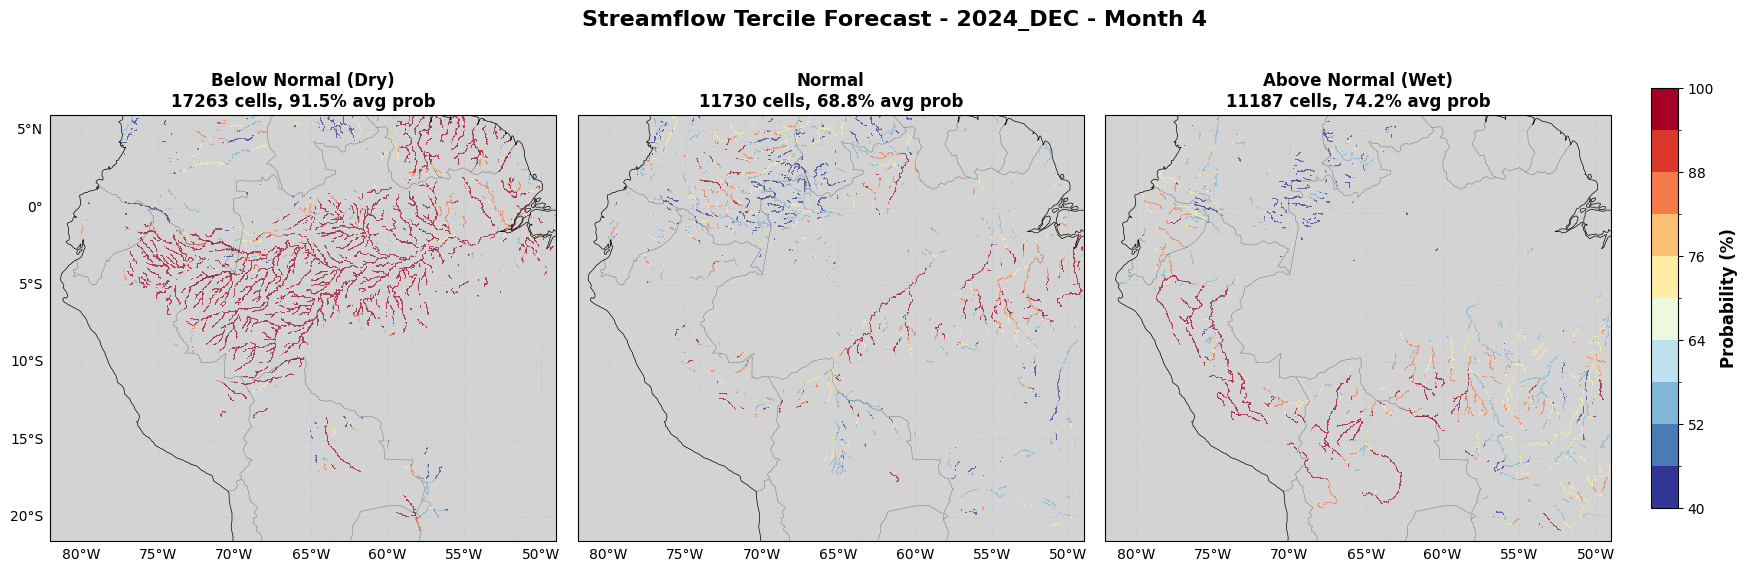

In [54]:
#Uncomment to create multi-category visualization:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

# Define colormap for probabilities
vmin, vmax = 40, 100  # Min tercile probability to max
n_colors = 10
cmap = plt.cm.get_cmap('RdYlBu_r', n_colors)  # Red=high prob, Blue=low prob
bounds = np.linspace(vmin, vmax, n_colors+1)
norm = BoundaryNorm(boundaries=bounds, ncolors=n_colors)

# Create figure with 3 subplots (one per category)
fig, axs = plt.subplots(
    1, 3,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(18, 6)
)

# Amazon basin extent
lis_output_bounds = [-82, -49, -21, 6]  # [min_lon, max_lon, min_lat, max_lat]

category_titles = {
    'cat_0': 'Below Normal (Dry)',
    'cat_1': 'Normal',
    'cat_2': 'Above Normal (Wet)'
}

# Plot each category
for idx, (cat_key, ax) in enumerate(zip(['cat_0', 'cat_1', 'cat_2'], axs)):
    gdf = fcst_gdf[cat_key]
    
    # Set map extent and features
    ax.set_extent(lis_output_bounds)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.3)
    ax.set_facecolor('lightgrey')
    
    # Plot river network if data exists
    if len(gdf) > 0:
        gdf.plot(
            column='probability',
            ax=ax,
            cmap=cmap,
            norm=norm,
            linewidth=0,
            alpha=0.7,
            legend=False
        )
        n_cells = len(gdf)
        mean_prob = gdf['probability'].mean()
        ax.set_title(f"{category_titles[cat_key]}\n{n_cells} cells, {mean_prob:.1f}% avg prob", 
                     fontsize=12, fontweight='bold')
    else:
        ax.set_title(f"{category_titles[cat_key]}\nNo data", fontsize=12)
    
    # Add gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if idx > 0:  # Only show y-labels on leftmost plot
        gl.left_labels = False

# Add colorbar
from matplotlib import colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='vertical')
cbar.set_label('Probability (%)', fontsize=12, fontweight='bold')

# Main title
fig.suptitle(f'Streamflow Tercile Forecast - {initialization_date.upper()} - Month {time_index+1}',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 0.91, 0.96])
plt.savefig(output_dir / f'streamflow_tercile_categories_{initialization_date}_month{time_index}.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# # Extract river networks for each tercile category (Actual streamflow)
# river_network = xr.open_dataset('../static/annual_mean_50cumecs_river_network.nc')
# river_mask = river_network['mask']

# #data_array = hindcast.isel(time=-1)  # Last time step for spatial structure
# streamflow_threshold = 40.0  # m³/s - adjust as needed
# time_index = 0 # First forecast month (can change or loop through all)

# print(f"\n{'='*60}")
# print(f"EXTRACTING RIVER NETWORKS")
# print(f"{'='*60}")
# print(f"Streamflow threshold: {streamflow_threshold} m³/s")
# print(f"{'='*60}")

# fcst_gdf = extract_river_network_by_category(
#      streamflow_data=river_mask, 
#      probability_data=probs_streamflow, 
#      flow_threshold=streamflow_threshold,
#      time_index= time_index

#  )

# #print(f"Extracted {len(fcst_gdf)} river cells")
# #print(fcst_gdf.head())